# Analysis of PAC comodulogram metrics 


In [10]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr 
from matplotlib.lines import Line2D

from figure_style import apply_style, set_panel_title, WT, NLGF
apply_style()

In [11]:
# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis')
LFP_CSV_PATH = basepath / 'concatenated_lfp_stats.csv' 
OUTPUT_DIR = LFP_CSV_PATH.parent.parent / 'LFP_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": NLGF, "WT": WT}

df = pd.read_csv(LFP_CSV_PATH)

# Clean names / categorical order
df["Genotype"] = pd.Categorical(df["Genotype"], categories=GENO_ORDER, ordered=True)
df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)
df["Experimenter"] = df["Experimenter"].astype(str)


## Run normality test for each metric

In [12]:
# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamm": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
    "theta_running_stderr": "Theta–running standard error",
    "theta_running_intercept_stderr": "Theta–running intercept standard error",
    "theta_gamma_modulation_index_fast_gamma": "Theta–Fast gamma modulation index",
    "theta_gamma_modulation_index_slow_gamma": "Theta–Slow gamma modulation index"
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}

# Run Shapiro-Wilk test for normality
from scipy.stats import shapiro
normality_results = {}
for metric in metrics.keys():
    stat, p_value = shapiro(df[metric].dropna())
    normality_results[metric] = (stat, p_value)
    print(f"Shapiro-Wilk test for {metric}: statistic={stat:.4f}, p-value={p_value:.4f}")
    print(f"Normality test for {metric}: {'Normal' if p_value > 0.05 else 'Not normal'}")


Shapiro-Wilk test for max_theta_freq: statistic=0.9696, p-value=0.4514
Normality test for max_theta_freq: Normal
Shapiro-Wilk test for comodulogram_PAC_slow_gamma: statistic=0.8932, p-value=0.0036
Normality test for comodulogram_PAC_slow_gamma: Not normal
Shapiro-Wilk test for comodulogram_PAC_fast_gamma: statistic=0.8599, p-value=0.0006
Normality test for comodulogram_PAC_fast_gamma: Not normal
Shapiro-Wilk test for n_oscillatory_epochs_slow_gamm: statistic=0.9319, p-value=0.0354
Normality test for n_oscillatory_epochs_slow_gamm: Not normal
Shapiro-Wilk test for n_oscillatory_epochs_fast_gamma: statistic=0.9254, p-value=0.0230
Normality test for n_oscillatory_epochs_fast_gamma: Not normal
Shapiro-Wilk test for theta_running_slope: statistic=0.9556, p-value=0.1935
Normality test for theta_running_slope: Normal
Shapiro-Wilk test for theta_running_intercept: statistic=0.9870, p-value=0.9539
Normality test for theta_running_intercept: Normal
Shapiro-Wilk test for theta_running_rvalue: sta

## Mann-Whitney analysis 

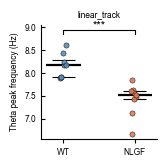

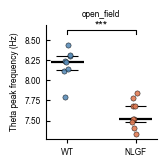

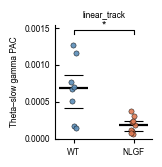

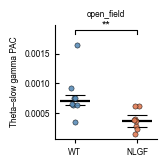

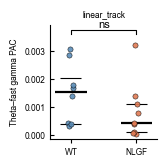

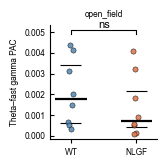

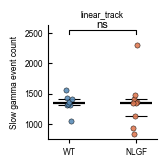

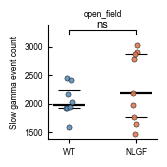

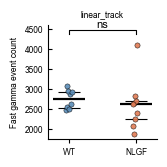

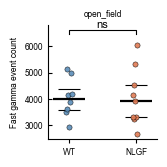

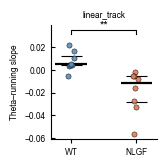

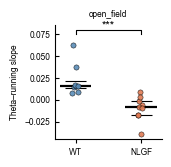

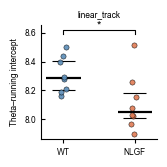

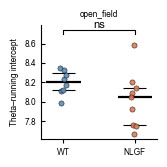

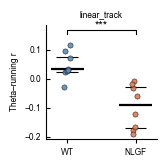

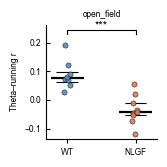

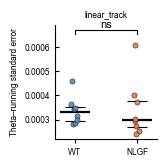

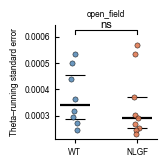

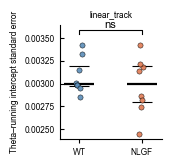

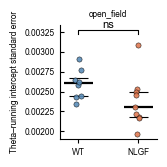

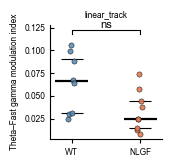

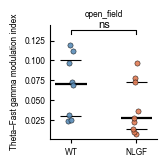

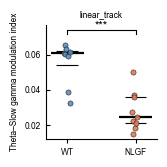

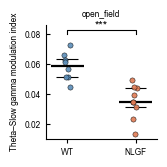

Done.
Saved results and figures to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis


In [13]:
"""
Analysis of PAC comodulogram metrics (modulation index, preferred phase) would follow a similar structure:
It will save:
lfp_stats_outputs/
  mannwhitney_results.csv
  <metric>_<task>_violin.pdf
  <metric>_<genotype>_paired_tasks.pdf).
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": NLGF, "WT": WT}

def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

# ─── Mann–Whitney tests: WT vs NLGF within each task ───────────────────────────
mw_results = []

for metric in metrics:
    for env in sorted(df["environment"].dropna().unique()):
        sub = df.loc[df["environment"] == env, ["Genotype", metric]].dropna()

        wt = sub.loc[sub["Genotype"] == "WT", metric].values
        ko = sub.loc[sub["Genotype"] == "NLGF", metric].values

        if len(wt) > 0 and len(ko) > 0:
            stat, p = mannwhitneyu(wt, ko, alternative="two-sided")
        else:
            stat, p = np.nan, np.nan

        mw_results.append({
            "metric": metric,
            "environment": env,
            "n_WT": len(wt),
            "n_NLGF": len(ko),
            "WT_median": np.nanmedian(wt) if len(wt) else np.nan,
            "NLGF_median": np.nanmedian(ko) if len(ko) else np.nan,
            "mannwhitney_U": stat,
            "pvalue": p,
            "stars": _pstars(p),
        })

mw_results = pd.DataFrame(mw_results)
mw_results.to_csv(os.path.join(OUTPUT_DIR, "mannwhitney_results.csv"), index=False)


# ─── Plotting helper ──────────────────────────────────────────────────────────
def plot_metric_violin(data, metric, ylabel, save=True):
    envs = sorted(data["environment"].dropna().unique())

    for env in envs:
        sub = data.loc[data["environment"] == env].copy()
        sub = sub[["Genotype", "mouse_name", metric]].dropna()

        genos = [g for g in GENO_ORDER if g in sub["Genotype"].astype(str).values]

        if len(genos) < 2:
            continue

        vals = {
            g: sub.loc[sub["Genotype"].astype(str) == g, metric].values
            for g in genos
        }

        fig, ax = plt.subplots(figsize=(1.65, 1.65))

        # ── Violin Mann–Whitney results ────────────────────────────────────────────────────
        # if all(len(vals[g]) >= 3 for g in genos):
        #     with warnings.catch_warnings():
        #         warnings.simplefilter("ignore")
        #         parts = ax.violinplot(
        #             [vals[g] for g in genos],
        #             positions=list(range(len(genos))),
        #             showmedians=False,
        #             showextrema=False,
        #             widths=0.8,
        #         )

        #     for i_v, pc in enumerate(parts["bodies"]):
        #         pc.set_facecolor(GENO_COLORS.get(genos[i_v], "#aaaaaa"))
        #         pc.set_alpha(0.45)
        #         pc.set_edgecolor("none")

        # ── Median and IQR ───────────────────────────────────────────────────
        for xi, g in enumerate(genos):
            if len(vals[g]) == 0:
                continue

            q1  = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3  = np.nanpercentile(vals[g], 75)

            ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                      colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24,
                      colors="black", linewidth=1.6, zorder=8)

        # ── Individual points ────────────────────────────────────────────────
        rng = np.random.default_rng(10)

        for xi, g in enumerate(genos):
            y = vals[g]
            jitter = rng.normal(0, 0.045, size=len(y))
            ax.scatter(
                np.full(len(y), xi) + jitter,
                y,
                s=14,
                color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
                zorder=10,
            )

        # ── P-valueannotation ──────────────────────────────────────────
        p_row = mw_results[
            (mw_results["metric"] == metric) &
            (mw_results["environment"] == env)
        ]

        if len(p_row):
            p = p_row["pvalue"].iloc[0]
            stars = _pstars(p)

            ymax = np.nanmax(sub[metric].values)
            ymin = np.nanmin(sub[metric].values)
            yrng = ymax - ymin if ymax > ymin else ymax * 0.1

            y = ymax + 0.12 * yrng
            h = 0.04 * yrng

            ax.plot([0, 0, 1, 1], [y, y+h, y+h, y],
                    color="black", linewidth=0.8, clip_on=False)
            ax.text(0.5, y+h, stars, ha="center", va="bottom", fontsize=8)

        # ── Axes ─────────────────────────────────────────────────────────────
        ax.set_xticks(range(len(genos)))
        ax.set_xticklabels(genos)
        ax.set_ylabel(ylabel)
        ax.set_title(env)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        fig.tight_layout()

        if save:
            clean_metric = metric.replace("/", "_")
            clean_env = env.replace(" ", "_")
            fig.savefig(
                os.path.join(OUTPUT_DIR, f"{clean_metric}_{clean_env}_violin.pdf")
            )
        plt.show()
        plt.close(fig)

# ─── Make all violin plots ────────────────────────────────────────────────────
for metric, ylabel in metrics.items():
    plot_metric_violin(df, metric, ylabel)    


print("Done.")
print(f"Saved results and figures to: {OUTPUT_DIR}")

## Plot the same graphs from Mann-Whitney but share the same y-axis for the 2 environments

,metric,environment,n_WT,n_NLGF,WT_median,NLGF_median,mannwhitney_U,pvalue,stars
0,max_theta_freq,open_field,8,9,8.232832,7.516384,71.0,0.000165,***
1,max_theta_freq,linear_track,8,9,8.171558,7.510185,72.0,0.000082,***
2,comodulogram_PAC_slow_gamma,open_field,8,8,0.000703,0.000375,59.0,0.002953,**
3,comodulogram_PAC_slow_gamma,linear_track,8,9,0.000687,0.000188,62.0,0.011107,*
4,comodulogram_PAC_fast_gamma,open_field,8,8,0.001761,0.000726,41.0,0.382284,ns
5,comodulogram_PAC_fast_gamma,linear_track,8,9,0.001543,0.000445,49.0,0.235870,ns
6,n_oscillatory_epochs_slow_gamm,open_field,8,9,1987.000000,2183.000000,28.0,0.480708,ns
7,n_oscillatory_epochs_slow_gamm,linear_track,8,9,1342.000000,1345.000000,38.0,0.888359,ns
8,n_oscillatory_epochs_fast_gamma,open_field,8,9,4016.500000,3918.000000,38.0,0.888359,ns
9,n_oscillatory_epochs_fast_gamma,linear_track,8,9,2761.000000,2627.000000,49.0,0.235870,ns


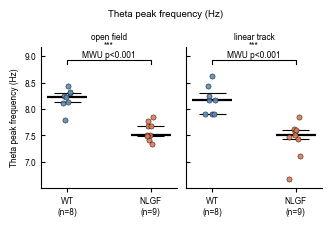

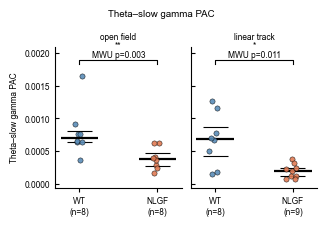

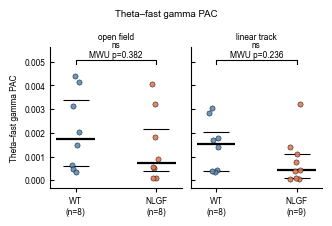

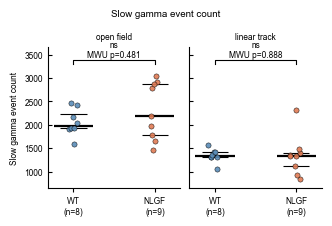

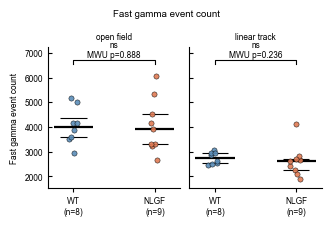

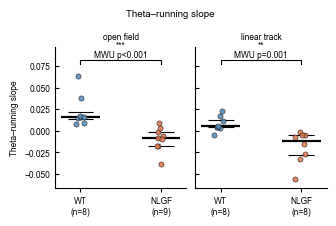

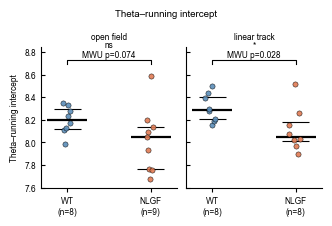

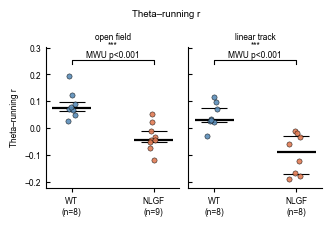

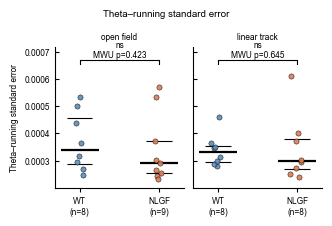

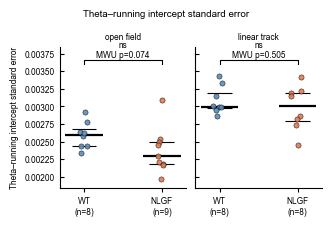

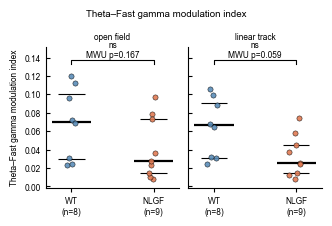

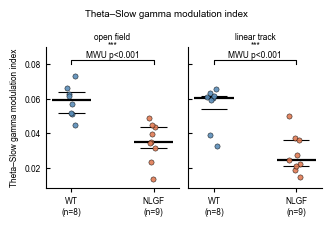

Done.
Saved shared y-axis plots to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/shared_yaxis_MWU_plots


In [15]:
# Shared y-axis Mann-Whitney plots for PAC comodulogram metrics
# Run after cell 4, where df and metrics are defined.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": NLGF, "WT": WT}

SHARED_Y_OUTDIR = os.path.join(OUTPUT_DIR, "shared_yaxis_MWU_plots")
os.makedirs(SHARED_Y_OUTDIR, exist_ok=True)


def _pstars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def _ptext(p):
    if pd.isna(p):
        return "MWU p=n/a"
    if p < 0.001:
        return "MWU p<0.001"
    return f"MWU p={p:.3f}"


def _clean_name(x):
    return str(x).replace("/", "_").replace(" ", "_")


# Put open field first, linear track second if both exist
preferred_env_order = ["open_field", "linear_track"]
envs_present = list(df["environment"].dropna().astype(str).unique())
envs = [e for e in preferred_env_order if e in envs_present]
envs += [e for e in sorted(envs_present) if e not in envs]

# Mann-Whitney tests: WT vs NLGF within each environment, same as your original cell
mw_rows = []

for metric in metrics:
    for env in envs:
        sub = df.loc[df["environment"].astype(str) == env, ["Genotype", metric]].dropna()

        wt = sub.loc[sub["Genotype"].astype(str) == "WT", metric].values
        ko = sub.loc[sub["Genotype"].astype(str) == "NLGF", metric].values

        if len(wt) > 0 and len(ko) > 0:
            stat, p = mannwhitneyu(wt, ko, alternative="two-sided")
        else:
            stat, p = np.nan, np.nan

        mw_rows.append({
            "metric": metric,
            "environment": env,
            "n_WT": len(wt),
            "n_NLGF": len(ko),
            "WT_median": np.nanmedian(wt) if len(wt) else np.nan,
            "NLGF_median": np.nanmedian(ko) if len(ko) else np.nan,
            "mannwhitney_U": stat,
            "pvalue": p,
            "stars": _pstars(p),
        })

mw_shared_y = pd.DataFrame(mw_rows)
mw_shared_y.to_csv(
    os.path.join(SHARED_Y_OUTDIR, "mannwhitney_results_shared_yaxis.csv"),
    index=False
)

display(mw_shared_y)


def plot_metric_shared_yaxis(data, metric, ylabel, save=True):
    plot_data = data[["environment", "Genotype", "mouse_name", metric]].dropna().copy()
    plot_data["environment"] = plot_data["environment"].astype(str)
    plot_data["Genotype"] = plot_data["Genotype"].astype(str)

    envs_for_metric = [e for e in envs if e in plot_data["environment"].unique()]
    if len(envs_for_metric) == 0:
        return

    fig, axes = plt.subplots(
        1,
        len(envs_for_metric),
        figsize=(1.65 * len(envs_for_metric), 2.2),
        sharey=True
    )

    if len(envs_for_metric) == 1:
        axes = [axes]

    y_all = plot_data.loc[plot_data["environment"].isin(envs_for_metric), metric].values
    ymin = np.nanmin(y_all)
    ymax = np.nanmax(y_all)
    yrng = ymax - ymin if ymax > ymin else max(abs(ymax), 1.0) * 0.1

    y_bracket = ymax + 0.12 * yrng
    h_bracket = 0.04 * yrng
    y_upper = ymax + 0.28 * yrng
    y_lower = ymin - 0.08 * yrng

    rng = np.random.default_rng(10)

    for ax, env in zip(axes, envs_for_metric):
        sub = plot_data.loc[plot_data["environment"] == env].copy()
        genos = [g for g in GENO_ORDER if g in sub["Genotype"].values]

        vals = {
            g: sub.loc[sub["Genotype"] == g, metric].values
            for g in genos
        }

        # Median and IQR, matching the existing plot style
        for xi, g in enumerate(genos):
            if len(vals[g]) == 0:
                continue

            q1 = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3 = np.nanpercentile(vals[g], 75)

            ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                      colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24,
                      colors="black", linewidth=1.6, zorder=8)

        # Individual points
        for xi, g in enumerate(genos):
            y = vals[g]
            jitter = rng.normal(0, 0.045, size=len(y))

            ax.scatter(
                np.full(len(y), xi) + jitter,
                y,
                s=14,
                color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
                zorder=10,
            )

        # Mann-Whitney annotation
        p_row = mw_shared_y[
            (mw_shared_y["metric"] == metric) &
            (mw_shared_y["environment"] == env)
        ]

        if len(p_row) and len(genos) >= 2:
            p = p_row["pvalue"].iloc[0]
            stars = p_row["stars"].iloc[0]
            label = f"{stars}\n{_ptext(p)}"

            ax.plot([0, 0, 1, 1],
                    [y_bracket, y_bracket + h_bracket,
                     y_bracket + h_bracket, y_bracket],
                    color="black", linewidth=0.8, clip_on=False)
            ax.text(0.5, y_bracket + h_bracket, label,
                    ha="center", va="bottom", fontsize=6)

        ax.set_xticks(range(len(genos)))
        ax.set_xticklabels([
            f"{g}\n(n={len(vals[g])})"
            for g in genos
        ])
        ax.set_title(env.replace("_", " "))
        ax.set_ylim(y_lower, y_upper)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(ylabel)

    for ax in axes[1:]:
        ax.set_ylabel("")

    fig.suptitle(ylabel, fontsize=7)
    fig.tight_layout()

    if save:
        fig.savefig(
            os.path.join(
                SHARED_Y_OUTDIR,
                f"{_clean_name(metric)}_openfield_lineartrack_shared_yaxis_MWU.pdf"
            )
        )

    plt.show()
    plt.close(fig)


for metric, ylabel in metrics.items():
    plot_metric_shared_yaxis(df, metric, ylabel)

print("Done.")
print(f"Saved shared y-axis plots to: {SHARED_Y_OUTDIR}")

## Generalized cell for all paired metrics with glmmTMB family selection:


- ✅ Loops over all paired metrics (PAC, n_oscillatory_epochs)
- ✅ Per environment (open_field, linear_track)
- ✅ Family selection (Gaussian vs Gamma vs Inverse Gaussian via AIC)
- ✅ Type III ANOVA + emmeans contrasts from best-fit family
- ✅ Organized output: Results saved to glmmTMB_paired_metrics/ subfolder
- ✅ Summary CSV: Shows which family won for each metric × environment combination

Results will include:

- {metric}_{env}_anova_{family}.csv
- {metric}_{env}_geno_by_band_{family}.csv
- {metric}_{env}_band_by_geno_{family}.csv
- {metric}_{env}_interaction_{family}.csv

In [5]:
# ── 2-way GLMM per environment for ALL PAIRED METRICS ────────────────────────
# Family selection: Gaussian vs Gamma vs Inverse Gaussian
# Metrics: PAC, n_oscillatory_epochs, theta_gamma_modulation_index (slow/fast variants)

import pandas as pd
import numpy as np
from pathlib import Path
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r("suppressPackageStartupMessages(library(glmmTMB))")
ro.r("suppressPackageStartupMessages(library(car))")
ro.r("suppressPackageStartupMessages(library(emmeans))")

def sig_label(p):
    if pd.isna(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ── Define all paired metrics (slow/fast pairs) ────────────────────────────────
PAIRED_METRICS = {
    'PAC': {
        'slow': 'comodulogram_PAC_slow_gamma',
        'fast': 'comodulogram_PAC_fast_gamma',
        'label': 'Theta–gamma PAC',
    },
    'n_oscillatory_epochs': {
        'slow': 'n_oscillatory_epochs_slow_gamm',
        'fast': 'n_oscillatory_epochs_fast_gamma',
        'label': 'N oscillatory epochs',
    },
    'theta_gamma_modulation_index': {
        'slow': 'theta_gamma_modulation_index_slow_gamma',
        'fast': 'theta_gamma_modulation_index_fast_gamma',
        'label': 'Theta–gamma modulation index',
    }
}

# Filter to metrics that exist in df
PAIRED_METRICS = {k: v for k, v in PAIRED_METRICS.items() 
                  if v['slow'] in df.columns and v['fast'] in df.columns}

if not PAIRED_METRICS:
    print("No paired metrics found in data")
else:
    print(f"Found {len(PAIRED_METRICS)} paired metrics: {list(PAIRED_METRICS.keys())}")

# ── Master results storage ─────────────────────────────────────────────────────
all_paired_results = {}
family_summary_all = []

# ── Loop over each paired metric ────────────────────────────────────────────────
for metric_name, metric_info in PAIRED_METRICS.items():
    print(f"\n\n{'='*80}")
    print(f"METRIC: {metric_name} ({metric_info['label']})")
    print(f"{'='*80}")
    
    all_paired_results[metric_name] = {}
    
    # ── Loop over each environment ─────────────────────────────────────────
    for env in sorted(df['environment'].dropna().unique()):
        print(f"\n{'─'*80}\nENVIRONMENT: {env}\n{'─'*80}")
        
        # Subset to this environment
        sub_df = df[df['environment'] == env].copy()
        
        # Build long-format (slow + fast) for this metric
        slow = sub_df[['mouse_name', 'Genotype', metric_info['slow']]].rename(
            columns={metric_info['slow']: 'value'})
        slow['gamma_band'] = 'slow'
        
        fast = sub_df[['mouse_name', 'Genotype', metric_info['fast']]].rename(
            columns={metric_info['fast']: 'value'})
        fast['gamma_band'] = 'fast'
        
        long_data = pd.concat([slow, fast], ignore_index=True).dropna(subset=['value'])
        
        # Handle zeros/negatives: add small offset for Gamma/IG families
        min_positive = long_data.loc[long_data['value'] > 0, 'value'].min()
        offset = min_positive / 2 if pd.notna(min_positive) else 1e-5
        long_data['value_offset'] = long_data['value'].apply(lambda x: x if x > 0 else offset)
        
        long_data['mouse_name']  = long_data['mouse_name'].astype(str)
        long_data['Genotype']    = long_data['Genotype'].astype(str)
        long_data['gamma_band']  = long_data['gamma_band'].astype(str)
        
        print(f"n rows = {len(long_data)}, n mice = {long_data['mouse_name'].nunique()}")
        print(f"{metric_name} range: [{long_data['value'].min():.6f}, {long_data['value'].max():.6f}]")
        print(f"Offset for zeros: {offset:.2e}")
        print(long_data.groupby(['Genotype', 'gamma_band'])['value'].agg(['count', 'median']))
        
        if long_data['mouse_name'].nunique() < 4:
            print("  ⚠️  Skipped: insufficient data")
            continue
        
        # ── Pass to R and fit GLMM with family selection ─────────────────────
        with localconverter(ro.default_converter + pandas2ri.converter):
            r_df = ro.conversion.py2rpy(long_data)
        ro.globalenv['dat'] = r_df
        
        r_code = """
        suppressWarnings({
            dat$mouse_name  <- factor(dat$mouse_name)
            dat$Genotype    <- factor(dat$Genotype,    levels = c("WT", "NLGF"))
            dat$gamma_band  <- factor(dat$gamma_band,  levels = c("slow", "fast"))
            
            contrasts(dat$Genotype)   <- contr.sum(nlevels(dat$Genotype))
            contrasts(dat$gamma_band) <- contr.sum(nlevels(dat$gamma_band))
            
            # ── Fit three families ──────────────────────────────────────────────
            fit_gaussian <- glmmTMB(
                value ~ Genotype * gamma_band + (1 | mouse_name),
                data = dat,
                family = gaussian()
            )
            
            fit_gamma <- glmmTMB(
                value_offset ~ Genotype * gamma_band + (1 | mouse_name),
                data = dat,
                family = Gamma(link = "log")
            )
            
            fit_igaussian <- glmmTMB(
                value_offset ~ Genotype * gamma_band + (1 | mouse_name),
                data = dat,
                family = inverse.gaussian(link = "log")
            )
            
            # ── Compare AICs ───────────────────────────────────────────────────
            aic_gaussian   <- AIC(fit_gaussian)
            aic_gamma      <- AIC(fit_gamma)
            aic_igaussian  <- AIC(fit_igaussian)
            
            aic_list <- c(gaussian = aic_gaussian, gamma = aic_gamma, igaussian = aic_igaussian)
            best_family_name <- names(which.min(aic_list))
            best_fit <- if (best_family_name == "gaussian") fit_gaussian
                       else if (best_family_name == "gamma") fit_gamma
                       else fit_igaussian
            
            delta_aic_min <- min(aic_list)
            delta_aic_from_best <- aic_list - delta_aic_min
            
            # ── Extract results from best fit via car::Anova (Type III) ─────────
            aov_table <- as.data.frame(Anova(best_fit, type = 3))
            aov_table <- data.frame(term = rownames(aov_table), aov_table,
                                    row.names = NULL, check.names = FALSE)
            
            # 1. Genotype contrast within each gamma band
            emm_geno_by_band <- emmeans(best_fit, ~ Genotype | gamma_band)
            geno_by_band_df  <- as.data.frame(contrast(emm_geno_by_band, method = "pairwise"))
            
            # 2. Gamma band contrast within each genotype
            emm_band_by_geno <- emmeans(best_fit, ~ gamma_band | Genotype)
            band_by_geno_df  <- as.data.frame(contrast(emm_band_by_geno, method = "pairwise"))
            
            # 3. Interaction contrast
            emm_full <- emmeans(best_fit, ~ Genotype * gamma_band)
            interaction_df <- as.data.frame(contrast(emm_full, interaction = "pairwise"))
            
            # Extract random effect variance and model fit info
            re_var  <- as.numeric(VarCorr(best_fit)$cond$mouse_name[1,1])
            aic_best <- AIC(best_fit)
            
            list(
                best_family        = best_family_name,
                aic_gaussian       = aic_gaussian,
                aic_gamma          = aic_gamma,
                aic_igaussian      = aic_igaussian,
                delta_aics         = delta_aic_from_best,
                aic_best           = aic_best,
                anova_table        = aov_table,
                geno_by_band       = geno_by_band_df,
                band_by_geno       = band_by_geno_df,
                interaction        = interaction_df,
                re_var             = re_var
            )
        })
        """
        
        try:
            out = ro.r(r_code)
            
            with localconverter(ro.default_converter + pandas2ri.converter):
                aov_df          = ro.conversion.rpy2py(out.rx2('anova_table'))
                geno_by_band    = ro.conversion.rpy2py(out.rx2('geno_by_band'))
                band_by_geno    = ro.conversion.rpy2py(out.rx2('band_by_geno'))
                interaction_df  = ro.conversion.rpy2py(out.rx2('interaction'))
            
            best_family = str(out.rx2('best_family')[0])
            aic_gaussian = float(out.rx2('aic_gaussian')[0])
            aic_gamma = float(out.rx2('aic_gamma')[0])
            aic_igaussian = float(out.rx2('aic_igaussian')[0])
            aic_best = float(out.rx2('aic_best')[0])
            re_var = float(out.rx2('re_var')[0])
            
            print(f"\n{'─'*70}")
            print(f"FAMILY SELECTION (Type III via car::Anova):")
            print(f"  Gaussian:        AIC = {aic_gaussian:.2f}")
            print(f"  Gamma:           AIC = {aic_gamma:.2f}")
            print(f"  Inverse Gaussian: AIC = {aic_igaussian:.2f}")
            print(f"  ✓ Best fit:      {best_family.upper()} (AIC = {aic_best:.2f})")
            print(f"{'─'*70}")
            
            print(f"\nModel fit (best family = {best_family}):")
            print(f"  AIC: {aic_best:.2f}  |  RE variance (mouse): {re_var:.6f}")
            
            print(f"\n─── Type III ANOVA ({best_family}) ───────────────────────────────────")
            print(aov_df.to_string(index=False))
            
            print(f"\n─── Genotype (NLGF vs WT) within each gamma band ────────")
            print(geno_by_band.to_string(index=False))
            
            print(f"\n─── Gamma band (fast vs slow) within each genotype ──────")
            print(band_by_geno.to_string(index=False))
            
            print(f"\n─── Interaction contrast ──────────────────────────────────")
            print(interaction_df.to_string(index=False))
            
            # Store for later reference
            all_paired_results[metric_name][env] = {
                'family': best_family,
                'aic_gaussian': aic_gaussian,
                'aic_gamma': aic_gamma,
                'aic_igaussian': aic_igaussian,
                'anova': aov_df,
                'geno_by_band': geno_by_band,
                'band_by_geno': band_by_geno,
                'interaction': interaction_df,
            }
            
            family_summary_all.append({
                'metric': metric_name,
                'environment': env,
                'best_family': best_family,
                'aic_gaussian': aic_gaussian,
                'aic_gamma': aic_gamma,
                'aic_igaussian': aic_igaussian,
                'n_mice': long_data['mouse_name'].nunique(),
            })
            
            # Save results
            env_clean = env.replace(" ", "_")
            metric_clean = metric_name.replace(" ", "_")
            out_dir = Path(OUTPUT_DIR) / 'glmmTMB_paired_metrics'
            out_dir.mkdir(parents=True, exist_ok=True)
            
            aov_df.to_csv(out_dir / f"{metric_clean}_{env_clean}_anova_{best_family}.csv", index=False)
            geno_by_band.to_csv(out_dir / f"{metric_clean}_{env_clean}_geno_by_band_{best_family}.csv", index=False)
            band_by_geno.to_csv(out_dir / f"{metric_clean}_{env_clean}_band_by_geno_{best_family}.csv", index=False)
            interaction_df.to_csv(out_dir / f"{metric_clean}_{env_clean}_interaction_{best_family}.csv", index=False)
            
            print(f"\n✅ Saved results for {metric_name} × {env} (family: {best_family})")
            
        except Exception as e:
            print(f"❌ FAILED: {e}")
            import traceback
            traceback.print_exc()

# ── Summary: families selected per metric × environment ────────────────────────
print(f"\n\n{'='*80}")
print("SUMMARY: FAMILIES SELECTED FOR ALL PAIRED METRICS")
print(f"{'='*80}")

if family_summary_all:
    summary_df = pd.DataFrame(family_summary_all)
    print(summary_df.to_string(index=False))
    
    # Save summary
    summary_path = Path(OUTPUT_DIR) / 'glmmTMB_paired_metrics' / "family_selection_summary_all_paired.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"\n✅ Family selection summary saved to: {summary_path}")

print(f"\n✅ All paired metrics analyzed and saved to: {Path(OUTPUT_DIR) / 'glmmTMB_paired_metrics'}")

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In check_dep_version(dep_pkg = "TMB") :  
R callback write-console:  package version mismatch: 
glmmTMB was built with TMB package version 1.9.19
Current TMB package version is 1.9.21
Please re-install glmmTMB from source or restore original ‘TMB’ package (see '?reinstalling' for more information)
  


Found 3 paired metrics: ['PAC', 'n_oscillatory_epochs', 'theta_gamma_modulation_index']


METRIC: PAC (Theta–gamma PAC)

────────────────────────────────────────────────────────────────────────────────
ENVIRONMENT: linear_track
────────────────────────────────────────────────────────────────────────────────
n rows = 34, n mice = 17
PAC range: [0.000043, 0.003230]
Offset for zeros: 2.16e-05
                     count    median
Genotype gamma_band                 
NLGF     fast            9  0.000445
         slow            9  0.000188
WT       fast            8  0.001543
         slow            8  0.000687

──────────────────────────────────────────────────────────────────────
FAMILY SELECTION (Type III via car::Anova):
  Gaussian:        AIC = -383.68
  Gamma:           AIC = -425.98
  Inverse Gaussian: AIC = -403.90
  ✓ Best fit:      GAMMA (AIC = -425.98)
──────────────────────────────────────────────────────────────────────

Model fit (best family = gamma):
  AIC: -425.98  |  RE v

## Compare GLMM-TMB vs Mann-Whitney U: concordance of genotype effects


This comparison uses the environment-specific GLMM-TMB genotype contrasts and compares them with Mann-Whitney U genotype tests for the same environment and original metric column.

For paired slow/fast metrics, GLMM-TMB rows are mapped back to the matching original slow/fast columns before merging with Mann-Whitney results.


In [6]:
# -- Compare GLMM-TMB vs Mann-Whitney U: genotype contrast concordance -----
from pathlib import Path
from IPython.display import display, HTML
import os
import numpy as np
import pandas as pd

ALPHA = 0.05
GLMM_DIR = Path(OUTPUT_DIR) / "glmmTMB_paired_metrics"
MW_PATH = Path(OUTPUT_DIR) / "mannwhitney_results.csv"

PAIRED_ORIGINAL_METRIC = {
    ("PAC", "slow"): "comodulogram_PAC_slow_gamma",
    ("PAC", "fast"): "comodulogram_PAC_fast_gamma",
    ("n_oscillatory_epochs", "slow"): "n_oscillatory_epochs_slow_gamm",
    ("n_oscillatory_epochs", "fast"): "n_oscillatory_epochs_fast_gamma",
    ("theta_gamma_modulation_index", "slow"): "theta_gamma_modulation_index_slow_gamma",
    ("theta_gamma_modulation_index", "fast"): "theta_gamma_modulation_index_fast_gamma",
}

PRETTY_METRIC = {
    "comodulogram_PAC_slow_gamma": "PAC slow",
    "comodulogram_PAC_fast_gamma": "PAC fast",
    "n_oscillatory_epochs_slow_gamm": "N oscillatory epochs slow",
    "n_oscillatory_epochs_fast_gamma": "N oscillatory epochs fast",
    "theta_gamma_modulation_index_slow_gamma": "Theta–Slow gamma modulation index",
    "theta_gamma_modulation_index_fast_gamma": "Theta–Fast gamma modulation index",
}

def sig_label(p):
    if pd.isna(p): return "NA"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def clean_key(value):
    return str(value).strip().lower().replace(" ", "_").replace("/", "_")

def p_value_column(table):
    for candidate in ["p.value", "pvalue", "Pr(>|z|)", "Pr(>|t|)", "p"]:
        if candidate in table.columns:
            return candidate
    candidates = [col for col in table.columns if "p" in str(col).lower()]
    return candidates[0] if candidates else None

def stat_column(table):
    for candidate in ["z.ratio", "t.ratio", "statistic"]:
        if candidate in table.columns:
            return candidate
    return None

def parse_geno_filename(path, env_lookup):
    """Parse {metric}_{environment}_geno_by_band_{family}.csv."""
    stem = path.name.removesuffix(".csv")
    if "_geno_by_band_" not in stem:
        return None

    for env_clean, env_label in sorted(env_lookup.items(), key=lambda item: len(item[0]), reverse=True):
        marker = f"_{env_clean}_geno_by_band_"
        if marker in stem:
            metric_name, family = stem.split(marker, 1)
            return metric_name, env_label, family
    return None

def extract_glmm_rows_from_table(table, metric_name, environment, family):
    rows = []
    p_col = p_value_column(table)
    s_col = stat_column(table)
    if p_col is None:
        return rows

    for _, row in table.iterrows():
        if "gamma_band" in table.columns and pd.notna(row.get("gamma_band")):
            gamma_band = str(row.get("gamma_band")).strip().lower()
        else:
            contrast_text = str(row.get("contrast", "")).lower()
            if "slow" in contrast_text:
                gamma_band = "slow"
            elif "fast" in contrast_text:
                gamma_band = "fast"
            else:
                continue

        original_metric = PAIRED_ORIGINAL_METRIC.get((metric_name, gamma_band))
        if original_metric is None:
            continue

        rows.append({
            "metric_group": metric_name,
            "gamma_band": gamma_band,
            "original_metric": original_metric,
            "metric": PRETTY_METRIC.get(original_metric, original_metric),
            "environment": environment,
            "environment_key": clean_key(environment),
            "glmm_family": family,
            "glmm_contrast": row.get("contrast", np.nan),
            "glmm_estimate": row.get("estimate", np.nan),
            "glmm_SE": row.get("SE", np.nan),
            "glmm_df": row.get("df", np.nan),
            "glmm_stat": row.get(s_col, np.nan) if s_col is not None else np.nan,
            "glmm_p": pd.to_numeric(row.get(p_col), errors="coerce"),
        })
    return rows

def extract_glmm_rows():
    rows = []

    if "all_paired_results" in globals() and isinstance(all_paired_results, dict) and all_paired_results:
        for metric_name, env_dict in all_paired_results.items():
            for environment, env_data in env_dict.items():
                table = env_data.get("geno_by_band")
                if table is None or len(table) == 0:
                    continue
                family = env_data.get("family", np.nan)
                rows.extend(extract_glmm_rows_from_table(table, metric_name, environment, family))

    if rows:
        return pd.DataFrame(rows)

    if not GLMM_DIR.exists():
        raise FileNotFoundError(f"GLMM-TMB results folder not found: {GLMM_DIR}")

    env_lookup = {clean_key(env): env for env in sorted(df["environment"].dropna().unique())}
    for path in sorted(GLMM_DIR.glob("*_geno_by_band_*.csv")):
        parsed = parse_geno_filename(path, env_lookup)
        if parsed is None:
            print(f"Skipping unrecognized GLMM filename: {path.name}")
            continue
        metric_name, environment, family = parsed
        table = pd.read_csv(path)
        rows.extend(extract_glmm_rows_from_table(table, metric_name, environment, family))

    return pd.DataFrame(rows)

# Load Mann-Whitney results from memory when available, otherwise from disk.
if "mw_results" in globals() and isinstance(mw_results, pd.DataFrame):
    mw_df = mw_results.copy()
elif MW_PATH.exists():
    mw_df = pd.read_csv(MW_PATH)
else:
    raise FileNotFoundError(f"Mann-Whitney results not found: {MW_PATH}")

glmm_df = extract_glmm_rows()
if glmm_df.empty:
    raise ValueError("No GLMM-TMB genotype-by-gamma-band contrast rows were extracted.")

required_mw_cols = [
    "metric", "environment", "n_WT", "n_NLGF", "WT_median", "NLGF_median", "mannwhitney_U", "pvalue"
]
missing = [col for col in required_mw_cols if col not in mw_df.columns]
if missing:
    raise KeyError(f"Mann-Whitney table is missing required columns: {missing}")

mw_for_comparison = (
    mw_df.loc[mw_df["metric"].isin(PAIRED_ORIGINAL_METRIC.values()), required_mw_cols]
    .rename(columns={"metric": "original_metric", "pvalue": "mwu_p"})
    .copy()
)
mw_for_comparison["environment_key"] = mw_for_comparison["environment"].map(clean_key)

comp = pd.merge(
    glmm_df,
    mw_for_comparison,
    on=["original_metric", "environment_key"],
    how="inner",
    suffixes=("", "_mwu"),
)

if comp.empty:
    raise ValueError(
        "No GLMM-TMB rows matched Mann-Whitney rows. Check environment labels and metric names."
    )

# Keep GLMM environment label and drop duplicate MW environment label.
if "environment_mwu" in comp.columns:
    comp = comp.drop(columns=["environment_mwu"])

comp["glmm_sig"] = comp["glmm_p"] < ALPHA
comp["mwu_sig"] = comp["mwu_p"] < ALPHA
comp["glmm_sig_label"] = comp["glmm_p"].map(sig_label)
comp["mwu_sig_label"] = comp["mwu_p"].map(sig_label)

def classify(row):
    if row["glmm_sig"] and row["mwu_sig"]:
        return "both_significant"
    if row["glmm_sig"] and not row["mwu_sig"]:
        return "glmmTMB_only"
    if (not row["glmm_sig"]) and row["mwu_sig"]:
        return "MWU_only"
    return "both_not_significant"

comp["concordance"] = comp.apply(classify, axis=1)
comp = comp.sort_values(["environment", "metric_group", "gamma_band"]).reset_index(drop=True)

full_path = Path(OUTPUT_DIR) / "glmmTMB_vs_mwu_concordance_by_gamma_band.csv"
sig_path = Path(OUTPUT_DIR) / "glmmTMB_vs_mwu_significant_results_by_gamma_band.csv"
comp.to_csv(full_path, index=False)
comp.loc[comp["glmm_sig"] | comp["mwu_sig"]].to_csv(sig_path, index=False)

print(f"Extracted GLMM-TMB rows: {len(glmm_df)}")
print(f"Matched comparisons: {len(comp)}")
print(f"Saved full concordance table: {full_path}")
print(f"Saved significant-results table: {sig_path}")

print("\nConcordance counts:")
print(comp["concordance"].value_counts(dropna=False).to_string())

print("\nConcordance by environment:")
print(pd.crosstab(comp["environment"], comp["concordance"]).to_string())

print("\nConcordance by gamma band:")
print(pd.crosstab(comp["gamma_band"], comp["concordance"]).to_string())

show_cols = [
    "metric", "environment", "gamma_band", "glmm_family",
    "glmm_estimate", "glmm_p", "glmm_sig_label",
    "mwu_p", "mwu_sig_label", "mannwhitney_U",
    "WT_median", "NLGF_median", "n_WT", "n_NLGF", "concordance",
]

display(HTML("<h3>GLMM-TMB vs Mann-Whitney U: genotype-effect concordance</h3>"))
display(
    comp[show_cols].style
    .format({
        "glmm_estimate": "{:.6f}",
        "glmm_p": "{:.4f}",
        "mwu_p": "{:.4f}",
        "mannwhitney_U": "{:.2f}",
        "WT_median": "{:.6f}",
        "NLGF_median": "{:.6f}",
    })
    .set_properties(**{"font-size": "11px"})
)

glmmTMB_vs_mwu = comp



Extracted GLMM-TMB rows: 12
Matched comparisons: 12
Saved full concordance table: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/glmmTMB_vs_mwu_concordance_by_gamma_band.csv
Saved significant-results table: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/glmmTMB_vs_mwu_significant_results_by_gamma_band.csv

Concordance counts:
concordance
both_not_significant    6
both_significant        2
glmmTMB_only            2
MWU_only                2

Concordance by environment:
concordance   MWU_only  both_not_significant  both_significant  glmmTMB_only
environment                                                                 
linear_track         0                     3                 2             1
open_field           2                     3                 0             1

Concordance by gamma band:
concordance  MWU_on

,metric,environment,gamma_band,glmm_family,glmm_estimate,glmm_p,glmm_sig_label,mwu_p,mwu_sig_label,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF,concordance
0,PAC fast,linear_track,fast,gamma,0.696215,0.1263,ns,0.2359,ns,49.00,0.001543,0.000445,8,9,both_not_significant
1,PAC slow,linear_track,slow,gamma,1.293322,0.0018,**,0.0111,*,62.00,0.000687,0.000188,8,9,both_significant
2,N oscillatory epochs fast,linear_track,fast,igaussian,0.073455,0.3770,ns,0.2359,ns,49.00,2761.000000,2627.000000,8,9,both_not_significant
3,N oscillatory epochs slow,linear_track,slow,igaussian,0.004831,0.9578,ns,0.8884,ns,38.00,1342.000000,1345.000000,8,9,both_not_significant
4,Theta–Fast gamma modulation index,linear_track,fast,gamma,0.653004,0.0041,**,0.0592,ns,56.00,0.066216,0.025016,8,9,glmmTMB_only
5,Theta–Slow gamma modulation index,linear_track,slow,gamma,0.677336,0.0029,**,0.0010,***,68.00,0.060694,0.024642,8,9,both_significant
6,PAC fast,open_field,fast,gamma,0.390746,0.2985,ns,0.3823,ns,41.00,0.001761,0.000726,8,8,both_not_significant
7,PAC slow,open_field,slow,gamma,0.726332,0.0533,ns,0.0030,**,59.00,0.000703,0.000375,8,8,MWU_only
8,N oscillatory epochs fast,open_field,fast,gamma,0.004906,0.9618,ns,0.8884,ns,38.00,4016.500000,3918.000000,8,9,both_not_significant
9,N oscillatory epochs slow,open_field,slow,gamma,-0.094066,0.3589,ns,0.4807,ns,28.00,1987.000000,2183.000000,8,9,both_not_significant


## FDR Correction Across MLM vs MWU Tests

The concordance table above compares raw p-values across metric × environment combinations (12 tests here). Running that many tests without correction inflates the false-positive rate — a handful of p-values in the 0.04-0.06 range are expected by chance alone.

This cell applies **Benjamini-Hochberg FDR correction** separately to the MLM p-values and the MWU p-values (each family corrected on its own, since they are different test families answering different statistical questions), then re-classifies concordance using the corrected significance calls.

**Interpretation:**
- `both_fdr` — significant in both tests after correction → the most trustworthy findings
- `MLM_only_fdr` / `MWU_only_fdr` — significant in one test but not the other after correction → treat as borderline; check for outlier-driven effects (e.g. via the animal-level violin plots) or run a robustness check (e.g. median-based permutation test)
- `neither_fdr` — not significant in either after correction

Re-run this cell any time `comp` is rebuilt (e.g. after adding new metrics).

In [7]:
# ── FDR correction (Benjamini-Hochberg) across all GLMM-TMB vs MWU tests ───────────
# Corrects for running one test per metric × environment combination.
# Adds *_p_fdr and *_sig_fdr columns to `comp`, plus a corrected concordance
# label. Depends on `comp` from the concordance cell above — re-run this any
# time `comp` is rebuilt (e.g. after adding new metrics).

from statsmodels.stats.multitest import multipletests

ALPHA = 0.05

def apply_fdr_correction(comp_df, alpha=ALPHA):
    """
    Applies Benjamini-Hochberg FDR correction separately to the GLMM-TMB and MWU
    p-value columns of the concordance table, and re-classifies concordance
    using the corrected p-values.

    The two families (GLMM-TMB, MWU) are corrected independently, since they are
    different test types answering different statistical questions — pooling
    them into one correction would not be appropriate.
    """
    comp_df = comp_df.copy()

    # GLMM-TMB correction
    glmm_mask = comp_df['glmm_p'].notna()
    comp_df.loc[glmm_mask, 'glmm_p_fdr'] = multipletests(
        comp_df.loc[glmm_mask, 'glmm_p'], method='fdr_bh'
    )[1]
    comp_df['glmm_sig_fdr'] = comp_df['glmm_p_fdr'] < alpha

    # MWU correction
    mwu_mask = comp_df['mwu_p'].notna()
    comp_df.loc[mwu_mask, 'mwu_p_fdr'] = multipletests(
        comp_df.loc[mwu_mask, 'mwu_p'], method='fdr_bh'
    )[1]
    comp_df['mwu_sig_fdr'] = comp_df['mwu_p_fdr'] < alpha

    # Re-classify concordance on FDR-corrected p-values
    def classify_fdr(row):
        g = bool(row['glmm_sig_fdr']) if pd.notna(row.get('glmm_sig_fdr')) else False
        m = bool(row['mwu_sig_fdr']) if pd.notna(row.get('mwu_sig_fdr')) else False
        if g and m:
            return 'both_fdr'
        if g:
            return 'GLMM-TMB_only_fdr'
        if m:
            return 'MWU_only_fdr'
        return 'neither_fdr'

    comp_df['concordance_fdr'] = comp_df.apply(classify_fdr, axis=1)
    return comp_df


comp_fdr = apply_fdr_correction(comp)

display(HTML("<h3>GLMM-TMB vs Mann-Whitney U — after Benjamini-Hochberg FDR correction</h3>"))
show_cols = ['metric', 'environment',
             'glmm_p', 'glmm_p_fdr', 'glmm_sig_fdr',
             'mwu_p', 'mwu_p_fdr', 'mwu_sig_fdr',
             'concordance', 'concordance_fdr']

def _colour_sig(row):
    g_sig = bool(row.get('glmm_sig_fdr'))
    m_sig = bool(row.get('mwu_sig_fdr'))
    if g_sig and m_sig:
        bg = "#c8e6c9"   # green — robust
    elif g_sig or m_sig:
        bg = "#fff9c4"   # yellow — borderline / method-dependent
    else:
        bg = ""
    return [f"background-color:{bg}" if bg else "" for _ in row]

display(
    comp_fdr[show_cols]
        .sort_values(['environment', 'metric'])
        .style
        .apply(_colour_sig, axis=1)
        .format({
            'glmm_p':     '{:.4f}',
            'glmm_p_fdr': '{:.4f}',
            'mwu_p':     '{:.4f}',
            'mwu_p_fdr': '{:.4f}',
        })
        .set_properties(**{'font-size': '11px'})
)

print("\n── Concordance counts BEFORE FDR correction ────────────────────────────")
print(comp_fdr['concordance'].value_counts().to_string())
print("\n── Concordance counts AFTER FDR correction ─────────────────────────────")
print(comp_fdr['concordance_fdr'].value_counts().to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
fdr_path = os.path.join(OUTPUT_DIR, "glmm-tmb_vs_mwu_concordance_FDR.csv")
comp_fdr.to_csv(fdr_path, index=False)
print(f"\n✅ Saved: {fdr_path}")

,metric,environment,glmm_p,glmm_p_fdr,glmm_sig_fdr,mwu_p,mwu_p_fdr,mwu_sig_fdr,concordance,concordance_fdr
2,N oscillatory epochs fast,linear_track,0.3770,0.4524,False,0.2359,0.3538,False,both_not_significant,neither_fdr
3,N oscillatory epochs slow,linear_track,0.9578,0.9618,False,0.8884,0.8884,False,both_not_significant,neither_fdr
0,PAC fast,linear_track,0.1263,0.2164,False,0.2359,0.3538,False,both_not_significant,neither_fdr
1,PAC slow,linear_track,0.0018,0.0164,True,0.0111,0.0333,True,both_significant,both_fdr
4,Theta–Fast gamma modulation index,linear_track,0.0041,0.0164,True,0.0592,0.1422,False,glmmTMB_only,GLMM-TMB_only_fdr
5,Theta–Slow gamma modulation index,linear_track,0.0029,0.0164,True,0.0010,0.0059,True,both_significant,both_fdr
8,N oscillatory epochs fast,open_field,0.9618,0.9618,False,0.8884,0.8884,False,both_not_significant,neither_fdr
9,N oscillatory epochs slow,open_field,0.3589,0.4524,False,0.4807,0.5768,False,both_not_significant,neither_fdr
6,PAC fast,open_field,0.2985,0.4478,False,0.3823,0.5097,False,both_not_significant,neither_fdr
7,PAC slow,open_field,0.0533,0.1066,False,0.0030,0.0118,True,MWU_only,MWU_only_fdr



── Concordance counts BEFORE FDR correction ────────────────────────────
concordance
both_not_significant    6
both_significant        2
glmmTMB_only            2
MWU_only                2

── Concordance counts AFTER FDR correction ─────────────────────────────
concordance_fdr
neither_fdr          7
both_fdr             2
MWU_only_fdr         2
GLMM-TMB_only_fdr    1

✅ Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/glmm-tmb_vs_mwu_concordance_FDR.csv


## Median-based permutation test Apply your median-based permutation test 
-specific discordant cells as a tiebreaker 
— it'll tell you whether the GLMM or the MWU is closer to the "outlier-robust truth."


In [8]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd

ALPHA = 0.05

base = Path(
    "/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/"
    "DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis"
)

data_path = base / "concatenated_lfp_stats.csv"
concordance_path = base / "glmmTMB_vs_mwu_concordance_by_gamma_band.csv"
out_path = base / "median_permutation_tiebreaker_discordant_glmmTMB_vs_mwu.csv"

lfp = pd.read_csv(data_path)
comp = pd.read_csv(concordance_path)

discordant = comp[comp["concordance"].isin(["glmmTMB_only", "MWU_only"])].copy()


def exact_median_permutation(values, labels, wt_label="WT", ko_label="NLGF"):
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels).astype(str)

    keep = np.isfinite(values) & np.isin(labels, [wt_label, ko_label])
    values = values[keep]
    labels = labels[keep]

    n_total = len(values)
    n_wt = int(np.sum(labels == wt_label))
    n_ko = int(np.sum(labels == ko_label))

    if n_wt == 0 or n_ko == 0:
        return None

    obs = float(
        np.nanmedian(values[labels == wt_label])
        - np.nanmedian(values[labels == ko_label])
    )
    abs_obs = abs(obs)

    diffs = []
    for wt_idx in combinations(range(n_total), n_wt):
        wt_mask = np.zeros(n_total, dtype=bool)
        wt_mask[list(wt_idx)] = True

        diff = float(
            np.nanmedian(values[wt_mask])
            - np.nanmedian(values[~wt_mask])
        )
        diffs.append(diff)

    diffs = np.asarray(diffs, dtype=float)

    return {
        "median_perm_stat_WT_minus_NLGF": obs,
        "median_perm_p_two_sided": float(np.mean(np.abs(diffs) >= abs_obs - 1e-15)),
        "median_perm_n_permutations": int(len(diffs)),
        "median_perm_null_mean": float(np.mean(diffs)),
        "median_perm_null_sd": float(np.std(diffs, ddof=1)),
        "median_perm_null_abs_ge_obs": int(np.sum(np.abs(diffs) >= abs_obs - 1e-15)),
        "median_perm_ci2p5": float(np.quantile(diffs, 0.025)),
        "median_perm_ci97p5": float(np.quantile(diffs, 0.975)),
    }


rows = []

for _, row in discordant.iterrows():
    env = row["environment"]
    metric_col = row["original_metric"]

    sub = lfp.loc[
        lfp["environment"].astype(str).eq(str(env)),
        ["mouse_name", "Genotype", metric_col],
    ].dropna()

    res = exact_median_permutation(
        sub[metric_col].to_numpy(),
        sub["Genotype"].to_numpy(),
    )

    if res is None:
        continue

    median_sig = res["median_perm_p_two_sided"] < ALPHA

    if median_sig == bool(row["glmm_sig"]) and median_sig != bool(row["mwu_sig"]):
        closer = "GLMM-TMB"
    elif median_sig == bool(row["mwu_sig"]) and median_sig != bool(row["glmm_sig"]):
        closer = "MWU"
    elif median_sig == bool(row["glmm_sig"]) == bool(row["mwu_sig"]):
        closer = "both"
    else:
        closer = "neither"

    rows.append({
        "metric_group": row["metric_group"],
        "gamma_band": row["gamma_band"],
        "original_metric": metric_col,
        "metric": row["metric"],
        "environment": env,
        "discordance": row["concordance"],
        "glmm_family": row["glmm_family"],
        "glmm_contrast": row["glmm_contrast"],
        "glmm_estimate": row["glmm_estimate"],
        "glmm_p": row["glmm_p"],
        "glmm_sig": bool(row["glmm_sig"]),
        "mwu_p": row["mwu_p"],
        "mwu_sig": bool(row["mwu_sig"]),
        "n_WT": int(row["n_WT"]),
        "n_NLGF": int(row["n_NLGF"]),
        "WT_median": row["WT_median"],
        "NLGF_median": row["NLGF_median"],
        **res,
        "median_perm_sig": median_sig,
        "tiebreaker_closer_to_median_truth": closer,
    })


out = (
    pd.DataFrame(rows)
    .sort_values(["environment", "metric_group", "gamma_band"])
    .reset_index(drop=True)
)

out.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(
    out[
        [
            "environment",
            "metric",
            "gamma_band",
            "discordance",
            "glmm_p",
            "mwu_p",
            "median_perm_p_two_sided",
            "median_perm_sig",
            "tiebreaker_closer_to_median_truth",
        ]
    ].to_string(index=False)
)

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/median_permutation_tiebreaker_discordant_glmmTMB_vs_mwu.csv
 environment                            metric gamma_band  discordance   glmm_p    mwu_p  median_perm_p_two_sided  median_perm_sig tiebreaker_closer_to_median_truth
linear_track Theta–Fast gamma modulation index       fast glmmTMB_only 0.004097 0.059235                 0.024887             True                          GLMM-TMB
  open_field                          PAC slow       slow     MWU_only 0.053301 0.002953                 0.013209             True                               MWU
  open_field Theta–Fast gamma modulation index       fast glmmTMB_only 0.048589 0.167174                 0.327026            False                               MWU
  open_field Theta–Slow gamma modulation index       slow     MWU_only 0.050485 0.000329                 0.001440             True          

In [9]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd

ALPHA = 0.05

base = Path(
    "/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/"
    "DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis"
)

data_path = base / "concatenated_lfp_stats.csv"
concordance_path = base / "glmm-tmb_vs_mwu_concordance_FDR.csv"
out_path = base / "median_permutation_tiebreaker_discordant_glmmTMB_vs_mwu_FDR.csv"

lfp = pd.read_csv(data_path)
comp = pd.read_csv(concordance_path)

discordant = comp[comp["concordance"].isin(["GLMM-TMB_only_fdr", "MWU_only_FDR"])].copy()


def exact_median_permutation(values, labels, wt_label="WT", ko_label="NLGF"):
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels).astype(str)

    keep = np.isfinite(values) & np.isin(labels, [wt_label, ko_label])
    values = values[keep]
    labels = labels[keep]

    n_total = len(values)
    n_wt = int(np.sum(labels == wt_label))
    n_ko = int(np.sum(labels == ko_label))

    if n_wt == 0 or n_ko == 0:
        return None

    obs = float(
        np.nanmedian(values[labels == wt_label])
        - np.nanmedian(values[labels == ko_label])
    )
    abs_obs = abs(obs)

    diffs = []
    for wt_idx in combinations(range(n_total), n_wt):
        wt_mask = np.zeros(n_total, dtype=bool)
        wt_mask[list(wt_idx)] = True

        diff = float(
            np.nanmedian(values[wt_mask])
            - np.nanmedian(values[~wt_mask])
        )
        diffs.append(diff)

    diffs = np.asarray(diffs, dtype=float)

    return {
        "median_perm_stat_WT_minus_NLGF": obs,
        "median_perm_p_two_sided": float(np.mean(np.abs(diffs) >= abs_obs - 1e-15)),
        "median_perm_n_permutations": int(len(diffs)),
        "median_perm_null_mean": float(np.mean(diffs)),
        "median_perm_null_sd": float(np.std(diffs, ddof=1)),
        "median_perm_null_abs_ge_obs": int(np.sum(np.abs(diffs) >= abs_obs - 1e-15)),
        "median_perm_ci2p5": float(np.quantile(diffs, 0.025)),
        "median_perm_ci97p5": float(np.quantile(diffs, 0.975)),
    }


rows = []

for _, row in discordant.iterrows():
    env = row["environment"]
    metric_col = row["original_metric"]

    sub = lfp.loc[
        lfp["environment"].astype(str).eq(str(env)),
        ["mouse_name", "Genotype", metric_col],
    ].dropna()

    res = exact_median_permutation(
        sub[metric_col].to_numpy(),
        sub["Genotype"].to_numpy(),
    )

    if res is None:
        continue

    median_sig = res["median_perm_p_two_sided"] < ALPHA

    if median_sig == bool(row["glmm_sig"]) and median_sig != bool(row["mwu_sig"]):
        closer = "GLMM-TMB"
    elif median_sig == bool(row["mwu_sig"]) and median_sig != bool(row["glmm_sig"]):
        closer = "MWU"
    elif median_sig == bool(row["glmm_sig"]) == bool(row["mwu_sig"]):
        closer = "both"
    else:
        closer = "neither"

    rows.append({
        "metric_group": row["metric_group"],
        "gamma_band": row["gamma_band"],
        "original_metric": metric_col,
        "metric": row["metric"],
        "environment": env,
        "discordance": row["concordance"],
        "glmm_family": row["glmm_family"],
        "glmm_contrast": row["glmm_contrast"],
        "glmm_estimate": row["glmm_estimate"],
        "glmm_p": row["glmm_p"],
        "glmm_sig": bool(row["glmm_sig"]),
        "mwu_p": row["mwu_p"],
        "mwu_sig": bool(row["mwu_sig"]),
        "n_WT": int(row["n_WT"]),
        "n_NLGF": int(row["n_NLGF"]),
        "WT_median": row["WT_median"],
        "NLGF_median": row["NLGF_median"],
        **res,
        "median_perm_sig": median_sig,
        "tiebreaker_closer_to_median_truth": closer,
    })


out = (
    pd.DataFrame(rows)
    .sort_values(["environment", "metric_group", "gamma_band"])
    .reset_index(drop=True)
)

out.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(
    out[
        [
            "environment",
            "metric",
            "gamma_band",
            "discordance",
            "glmm_p",
            "mwu_p",
            "median_perm_p_two_sided",
            "median_perm_sig",
            "tiebreaker_closer_to_median_truth",
        ]
    ].to_string(index=False)
)

KeyError: 'environment'

In [ ]:
# -- Significant GLMM-TMB / Mann-Whitney U results summary -------------------
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd

ALPHA = 0.05
summary_path = Path(OUTPUT_DIR) / "glmmTMB_vs_mwu_significant_results_by_gamma_band.csv"
full_path = Path(OUTPUT_DIR) / "glmmTMB_vs_mwu_concordance_by_gamma_band.csv"

if "glmmTMB_vs_mwu" in globals():
    sig_summary = glmmTMB_vs_mwu.loc[
        glmmTMB_vs_mwu["glmm_sig"] | glmmTMB_vs_mwu["mwu_sig"]
    ].copy()
elif summary_path.exists():
    sig_summary = pd.read_csv(summary_path)
elif full_path.exists():
    full = pd.read_csv(full_path)
    sig_summary = full.loc[full["glmm_sig"] | full["mwu_sig"]].copy()
else:
    raise FileNotFoundError(
        "Run the GLMM-TMB vs Mann-Whitney concordance cell first."
    )

ordered_cols = [
    "metric", "environment", "gamma_band", "glmm_family",
    "glmm_estimate", "glmm_p", "glmm_sig_label",
    "mwu_p", "mwu_sig_label", "mannwhitney_U",
    "WT_median", "NLGF_median", "n_WT", "n_NLGF", "concordance",
]
ordered_cols = [col for col in ordered_cols if col in sig_summary.columns]

sig_summary = sig_summary.sort_values(["environment", "metric", "gamma_band"]).reset_index(drop=True)
sig_summary.to_csv(summary_path, index=False)

print(f"Significant GLMM-TMB or Mann-Whitney rows: {len(sig_summary)}")
print(f"Saved: {summary_path}")

if sig_summary.empty:
    print(f"No significant GLMM-TMB or Mann-Whitney genotype contrasts at alpha = {ALPHA}.")
else:
    display(HTML("<h3>Significant GLMM-TMB or Mann-Whitney U genotype effects</h3>"))
    display(
        sig_summary[ordered_cols].style
        .format({
            "glmm_estimate": "{:.6f}",
            "glmm_p": "{:.4f}",
            "mwu_p": "{:.4f}",
            "mannwhitney_U": "{:.2f}",
            "WT_median": "{:.6f}",
            "NLGF_median": "{:.6f}",
        })
        .set_properties(**{"font-size": "11px"})
    )



Significant GLMM-TMB or Mann-Whitney rows: 6
Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/glmmTMB_vs_mwu_significant_results_by_gamma_band.csv


,metric,environment,gamma_band,glmm_family,glmm_estimate,glmm_p,glmm_sig_label,mwu_p,mwu_sig_label,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF,concordance
0,PAC slow,linear_track,slow,gamma,1.293371,0.0018,**,0.0111,*,62.00,0.000687,0.000188,8,9,both_significant
1,Theta–Fast gamma modulation index,linear_track,fast,gamma,0.653004,0.0041,**,0.0592,ns,56.00,0.066216,0.025016,8,9,glmmTMB_only
2,Theta–Slow gamma modulation index,linear_track,slow,gamma,0.677336,0.0029,**,0.0010,***,68.00,0.060694,0.024642,8,9,both_significant
3,PAC slow,open_field,slow,gamma,0.829007,0.0429,*,0.0016,**,67.00,0.000703,0.000363,8,9,both_significant
4,Theta–Fast gamma modulation index,open_field,fast,gamma,0.517540,0.0486,*,0.1672,ns,51.00,0.070421,0.027308,8,9,glmmTMB_only
5,Theta–Slow gamma modulation index,open_field,slow,gamma,0.513250,0.0505,ns,0.0003,***,70.00,0.059081,0.034943,8,9,MWU_only


## Two-way Linear Mixed-effects model per environmnet 
- PAC ~ Genotype * gamma_band + (1 | mouse_name) --> LMER (GAUSSIAN) - do not use


In [ ]:
# # ── 2-way mixed model per environment: PAC ~ Genotype * gamma_band + (1 | mouse_name) ────

# from rpy2.robjects import pandas2ri
# import pandas as pd
# import numpy as np
# from pathlib import Path
# import rpy2.robjects as ro
# from rpy2.robjects.conversion import localconverter

# ro.r("suppressPackageStartupMessages(library(lme4))")
# ro.r("suppressPackageStartupMessages(library(lmerTest))")
# ro.r("suppressPackageStartupMessages(library(emmeans))")

# SLOW_COL = 'comodulogram_PAC_slow_gamma'
# FAST_COL = 'comodulogram_PAC_fast_gamma'

# def sig_label(p):
#     if pd.isna(p): return 'NA'
#     if p < 0.001: return '***'
#     if p < 0.01:  return '**'
#     if p < 0.05:  return '*'
#     return 'ns'

# # ── Loop over each environment ─────────────────────────────────────────────────
# all_env_results = {}

# for env in sorted(df['environment'].dropna().unique()):
#     print(f"\n{'='*70}\nENVIRONMENT: {env}\n{'='*70}")
    
#     # Subset to this environment
#     sub_df = df[df['environment'] == env].copy()
    
#     # Build long-format PAC (slow + fast) for this environment
#     slow = sub_df[['mouse_name', 'Genotype', SLOW_COL]].rename(columns={SLOW_COL: 'PAC'})
#     slow['gamma_band'] = 'slow'
#     fast = sub_df[['mouse_name', 'Genotype', FAST_COL]].rename(columns={FAST_COL: 'PAC'})
#     fast['gamma_band'] = 'fast'
    
#     long_pac = pd.concat([slow, fast], ignore_index=True).dropna(subset=['PAC'])
#     long_pac['mouse_name']  = long_pac['mouse_name'].astype(str)
#     long_pac['Genotype']    = long_pac['Genotype'].astype(str)
#     long_pac['gamma_band']  = long_pac['gamma_band'].astype(str)
    
#     print(f"n rows = {len(long_pac)}, n mice = {long_pac['mouse_name'].nunique()}")
#     print(long_pac.groupby(['Genotype', 'gamma_band'])['PAC'].agg(['count', 'median']))
    
#     if long_pac['mouse_name'].nunique() < 4:
#         print("  Skipped: insufficient data")
#         continue
    
#     # ── Pass to R and fit 2-way model (no environment term) ─────────────────
#     with localconverter(ro.default_converter + pandas2ri.converter):
#         r_df = ro.conversion.py2rpy(long_pac)
#     ro.globalenv['dat'] = r_df
    
#     r_code = f"""
#     suppressWarnings({{
#         dat$mouse_name  <- factor(dat$mouse_name)
#         dat$Genotype    <- factor(dat$Genotype,    levels = c("WT", "NLGF"))
#         dat$gamma_band  <- factor(dat$gamma_band,  levels = c("slow", "fast"))
        
#         contrasts(dat$Genotype)   <- contr.sum(nlevels(dat$Genotype))
#         contrasts(dat$gamma_band) <- contr.sum(nlevels(dat$gamma_band))
        
#         # 2-way model: PAC ~ Genotype * gamma_band + (1 | mouse_name)
#         fit <- lmer(PAC ~ Genotype * gamma_band + (1 | mouse_name),
#                     data = dat, REML = FALSE)
        
#         # Type III ANOVA
#         aov_table <- as.data.frame(anova(fit, type = 3))
#         aov_table <- data.frame(term = rownames(aov_table), aov_table,
#                                 row.names = NULL, check.names = FALSE)
        
#         # 1. Genotype contrast within each gamma band
#         emm_geno_by_band <- emmeans(fit, ~ Genotype | gamma_band)
#         geno_by_band_df  <- as.data.frame(contrast(emm_geno_by_band, method = "pairwise"))
        
#         # 2. Gamma band contrast within each genotype
#         emm_band_by_geno <- emmeans(fit, ~ gamma_band | Genotype)
#         band_by_geno_df  <- as.data.frame(contrast(emm_band_by_geno, method = "pairwise"))
        
#         # 3. Interaction contrast
#         emm_full <- emmeans(fit, ~ Genotype * gamma_band)
#         interaction_df <- as.data.frame(contrast(emm_full, interaction = "pairwise"))
        
#         re_var  <- as.numeric(VarCorr(fit)$mouse_name[1,1])
#         aic_val <- AIC(fit)
        
#         list(
#             anova_table        = aov_table,
#             geno_by_band       = geno_by_band_df,
#             band_by_geno       = band_by_geno_df,
#             interaction        = interaction_df,
#             re_var            = re_var,
#             aic               = aic_val
#         )
#     }})
#     """
    
#     try:
#         out = ro.r(r_code)
        
#         with localconverter(ro.default_converter + pandas2ri.converter):
#             aov_df          = ro.conversion.rpy2py(out.rx2('anova_table'))
#             geno_by_band    = ro.conversion.rpy2py(out.rx2('geno_by_band'))
#             band_by_geno    = ro.conversion.rpy2py(out.rx2('band_by_geno'))
#             interaction_df  = ro.conversion.rpy2py(out.rx2('interaction'))
        
#         re_var  = float(out.rx2('re_var')[0])
#         aic_val = float(out.rx2('aic')[0])
        
#         print(f"\nAIC: {aic_val:.2f}  |  RE variance (mouse): {re_var:.6f}")
        
#         print("\n─── Type III ANOVA ───────────────────────────────────────")
#         print(aov_df.to_string(index=False))
        
#         print("\n─── Genotype (NLGF vs WT) within each gamma band ────────")
#         print(geno_by_band.to_string(index=False))
        
#         print("\n─── Gamma band (fast vs slow) within each genotype ──────")
#         print(band_by_geno.to_string(index=False))
        
#         print("\n─── Interaction contrast ──────────────────────────────────")
#         print(interaction_df.to_string(index=False))
        
#         # Store for later reference
#         all_env_results[env] = {
#             'anova': aov_df,
#             'geno_by_band': geno_by_band,
#             'band_by_geno': band_by_geno,
#             'interaction': interaction_df,
#         }
        
#         # Save results
#         env_clean = env.replace(" ", "_")
#         out_dir = Path(OUTPUT_DIR)
#         out_dir.mkdir(parents=True, exist_ok=True)
        
#         aov_df.to_csv(out_dir / f"PAC_lmer_2way_{env_clean}_anova.csv", index=False)
#         geno_by_band.to_csv(out_dir / f"PAC_lmer_2way_{env_clean}_geno_by_band.csv", index=False)
#         band_by_geno.to_csv(out_dir / f"PAC_lmer_2way_{env_clean}_band_by_geno.csv", index=False)
#         interaction_df.to_csv(out_dir / f"PAC_lmer_2way_{env_clean}_interaction.csv", index=False)
        
#         print(f"\n✅ Saved results for {env}")
        
#     except Exception as e:
#         print(f"FAILED: {e}")

# print(f"\n{'='*70}")
# print(f"✅ All environment-specific models completed and saved to: {OUTPUT_DIR}")

## Repeated measures ANOVA 

In [ ]:
# # ── Repeated-measures ANOVA (R via rpy2): gamma_band (within) × Genotype (between) ──
# import pandas as pd
# import numpy as np
# from pathlib import Path
# import rpy2.robjects as ro
# from rpy2.robjects import pandas2ri
# from rpy2.robjects.conversion import localconverter

# ro.r("suppressPackageStartupMessages(library(afex))")

# # ── Load data ──────────────────────────────────────────────────────────────
# OUTPUT_DIR = LFP_CSV_PATH.parent / 'PAC_rm_anova_R_by_env'
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# df = pd.read_csv(LFP_CSV_PATH)
# df['mouse_name']  = df['mouse_name'].astype(str)
# df['Genotype']    = df['Genotype'].astype(str)
# df['environment'] = df['environment'].astype(str)

# SLOW_COL = 'comodulogram_PAC_slow_gamma'
# FAST_COL = 'comodulogram_PAC_fast_gamma'

# def sig_label(p):
#     if pd.isna(p): return 'NA'
#     if p < 0.001: return '***'
#     if p < 0.01:  return '**'
#     if p < 0.05:  return '*'
#     return 'ns'

# def build_long_pac(sub_env):
#     slow = sub_env[['mouse_name', 'Genotype', SLOW_COL]].rename(columns={SLOW_COL: 'PAC'})
#     slow['gamma_band'] = 'slow'
#     fast = sub_env[['mouse_name', 'Genotype', FAST_COL]].rename(columns={FAST_COL: 'PAC'})
#     fast['gamma_band'] = 'fast'
#     return pd.concat([slow, fast], ignore_index=True).dropna(subset=['PAC'])

# def run_rm_anova_R(long_df):
#     """Fit PAC ~ Genotype * gamma_band with mouse_name as within-subject error term, via afex::aov_ez."""
#     with localconverter(ro.default_converter + pandas2ri.converter):
#         r_df = ro.conversion.py2rpy(long_df)
#     ro.globalenv['dat'] = r_df

#     r_code = """
#     suppressWarnings({
#         dat$mouse_name <- factor(dat$mouse_name)
#         dat$Genotype   <- factor(dat$Genotype, levels = c("WT", "NLGF"))
#         dat$gamma_band <- factor(dat$gamma_band, levels = c("slow", "fast"))
#         dat <- droplevels(dat)

#         fit <- aov_ez(
#             id      = "mouse_name",
#             dv      = "PAC",
#             data    = dat,
#             between = "Genotype",
#             within  = "gamma_band",
#             type    = 3,
#             anova_table = list(correction = "GG")   # Greenhouse-Geisser, moot here w/ 2 levels but safe default
#         )

#         aov_df <- as.data.frame(fit$anova_table)
#         aov_df <- data.frame(term = rownames(aov_df), aov_df, row.names = NULL, check.names = FALSE)

#         list(anova_table = aov_df)
#     })
#     """
#     out = ro.r(r_code)
#     with localconverter(ro.default_converter + pandas2ri.converter):
#         aov_df = ro.conversion.rpy2py(out.rx2('anova_table'))
#     return aov_df

# # ── Run separately per environment ───────────────────────────────────────────
# all_results = {}
# rm_rows_summary = []

# for env in sorted(df['environment'].dropna().unique()):
#     print(f"\n{'='*70}\nENVIRONMENT: {env}\n{'='*70}")

#     sub_env  = df[df['environment'] == env].copy()
#     long_pac = build_long_pac(sub_env)

#     # ── Check balance: every mouse must have exactly 2 rows (slow + fast) ────
#     counts = long_pac.groupby('mouse_name').size()
#     unbalanced = counts[counts != 2]
#     if len(unbalanced) > 0:
#         print(f"⚠️  Unbalanced design — these mice don't have both gamma bands, dropping them:")
#         print(unbalanced)
#         long_pac = long_pac[~long_pac['mouse_name'].isin(unbalanced.index)]

#     n_mice = long_pac['mouse_name'].nunique()
#     print(f"n rows = {len(long_pac)}, n mice (balanced) = {n_mice}, "
#           f"genotypes = {sorted(long_pac['Genotype'].unique())}")

#     if n_mice < 4:
#         print("  Skipped: insufficient balanced data")
#         continue

#     try:
#         aov_df = run_rm_anova_R(long_pac)
#         print("\nRepeated-measures ANOVA (afex::aov_ez, Type III):")
#         print(aov_df.to_string(index=False))

#         all_results[env] = aov_df

#         # afex column names: 'num Df', 'den Df', 'MSE', 'F', 'ges', 'Pr(>F)'
#         p_col = [c for c in aov_df.columns if 'Pr' in c][0]
#         for _, row in aov_df.iterrows():
#             rm_rows_summary.append({
#                 'environment': env,
#                 'term':        row['term'],
#                 'F':           row.get('F', np.nan),
#                 'p_value':     row.get(p_col, np.nan),
#                 'sig':         sig_label(row.get(p_col, np.nan)),
#             })

#         aov_df.to_csv(OUTPUT_DIR / f"PAC_rm_anova_R_{env}.csv", index=False)
#         print(f"Saved: {OUTPUT_DIR / f'PAC_rm_anova_R_{env}.csv'}")

#     except Exception as e:
#         print(f"  FAILED: {e}")

# df_summary = pd.DataFrame(rm_rows_summary)
# summary_path = OUTPUT_DIR / "PAC_rm_anova_R_summary_both_envs.csv"
# df_summary.to_csv(summary_path, index=False)
# print(f"\n✅ Combined summary saved to: {summary_path}")
# print(df_summary.to_string(index=False))